<a href="https://colab.research.google.com/github/Andrew-lee0615/Quant-Strategies/blob/main/Strategy_01_SMA_Crossover_SPY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

/tmp/ipykernel_7575/2568951064.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')
[*********************100%***********************]  1 of 1 completed


--- SPY Final score ---
1. Total amount of investment: $410,200
2. Total value of account: $753,226.01
3. Total return: 83.62%
4. CAGR: 6.27%
5. MDD: -27.49%
----------------------------------------


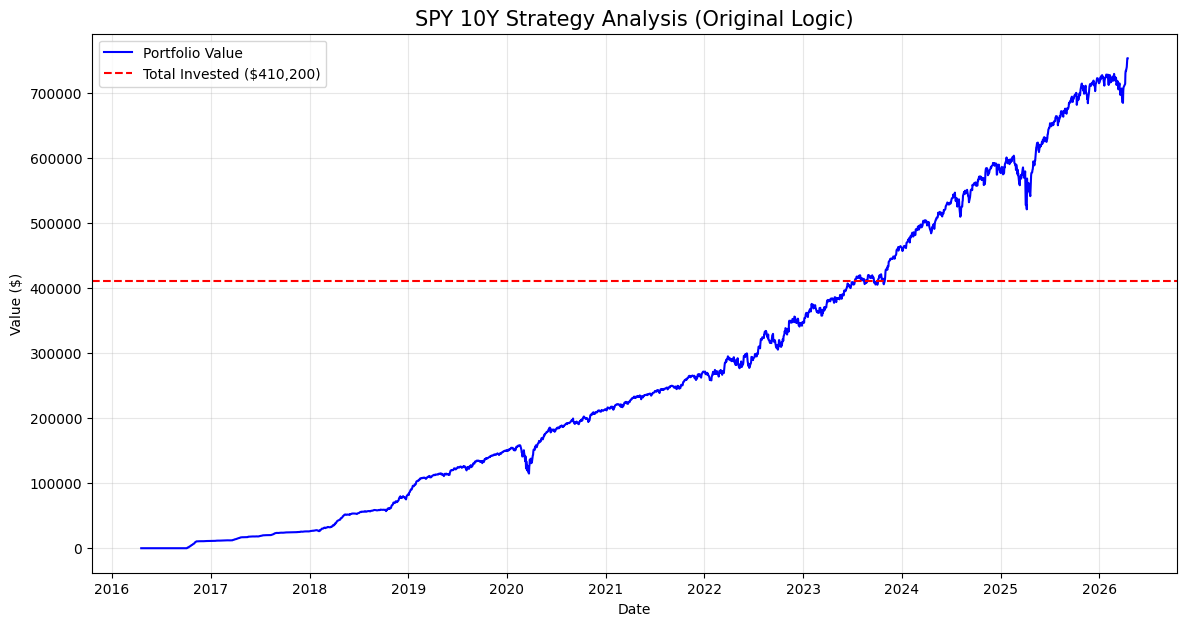

In [14]:

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. data (10yrs)
ticker = 'SPY'
df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')

# 2. MA calculation
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()
df['MA120'] = df['Close'].rolling(window=120).mean()

# 3. simulation
cash = 0
shares = 0
total_invested = 0
portfolio_values = []

# 4. backtesting loof
for i in range(len(df)):
    current_price = df['Close'].iloc[i]
    ma20 = df['MA20'].iloc[i]
    ma60 = df['MA60'].iloc[i]
    ma120 = df['MA120'].iloc[i]

    if pd.isna(ma120):
        portfolio_values.append(0)
        continue

    # buy logic
    buy_amount = 0
    if current_price <= ma120:
        buy_amount = 600
    elif current_price <= ma60:
        buy_amount = 400
    elif current_price <= ma20:
        buy_amount = 200

    if buy_amount > 0:
        shares += buy_amount / current_price
        total_invested += buy_amount

    # 10% sell logic
    if current_price >= ma20 * 1.10 and shares > 0:
        sell_shares = shares * 0.2
        cash += sell_shares * current_price
        shares -= sell_shares

    # total value
    portfolio_values.append((shares * current_price) + cash)

df['Portfolio_Value'] = portfolio_values

# 5. calculation
# MDD calculation
df['Peak'] = df['Portfolio_Value'].cummax()
df['Drawdown'] = (df['Portfolio_Value'] - df['Peak']) / df['Peak']
final_mdd = df['Drawdown'].min() * 100

# total account value & CAGR
final_val = df['Portfolio_Value'].iloc[-1]
total_return = ((final_val - total_invested) / total_invested) * 100
years = 10
cagr = (((final_val / total_invested) ** (1/years)) - 1) * 100

# 6. Final score
print(f"--- {ticker} Final score ---")
print(f"1. Total amount of investment: ${total_invested:,.0f}")
print(f"2. Total value of account: ${final_val:,.2f}")
print(f"3. Total return: {total_return:.2f}%")
print(f"4. CAGR: {cagr:.2f}%")
print(f"5. MDD: {final_mdd:.2f}%")
print("-" * 40)

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Portfolio_Value'], label='Portfolio Value', color='blue')
plt.axhline(y=total_invested, color='red', linestyle='--', label=f'Total Invested (${total_invested:,.0f})')
plt.title(f'{ticker} 10Y Strategy Analysis (Original Logic)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()